# Dados


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal as mv_norm

from utils.data import generate_data
from utils.plot import plot_2D, plot_features

# Caminho relativo (funciona de qualquer lugar)
# data_path = Path("..") / "data" / "raw" / "gaussianas.csv"
# df = pd.read_csv(data_path)

# Estrutura do projeto

## Pipeline — Selective Classification

1. `data_generation(params)` → `X, y, g`

2. `get_posteriors(X, params)` → `posteriors` _(shape: N × K)_

3. `classifier(posteriors, confidence_fn)` → `y_hat, confidence`
   - `confidence_fn`: max_prob (default), margem, entropia, …

4. `selector(posteriors, g=None)` → `accept` _(shape: N, bool)_
   - threshold simples: usa `confidence` interna
   - plugin L2R (Narasimhan): usa `posteriors` + `g` diretamente
   - `.fit()` / `.predict()` — TODO: implementar

5. `metrics(y, y_hat, accept, g)` → `risk, ber, wg, coverage`
   - `risk`: risco total (com custo de rejeição)
   - `ber`: balanced error rate (sem custo de rejeição)
   - `wg`: weighted gain (com custo de rejeição)
   - `coverage`: proporção de amostras aceitas


# Funções auxiliares


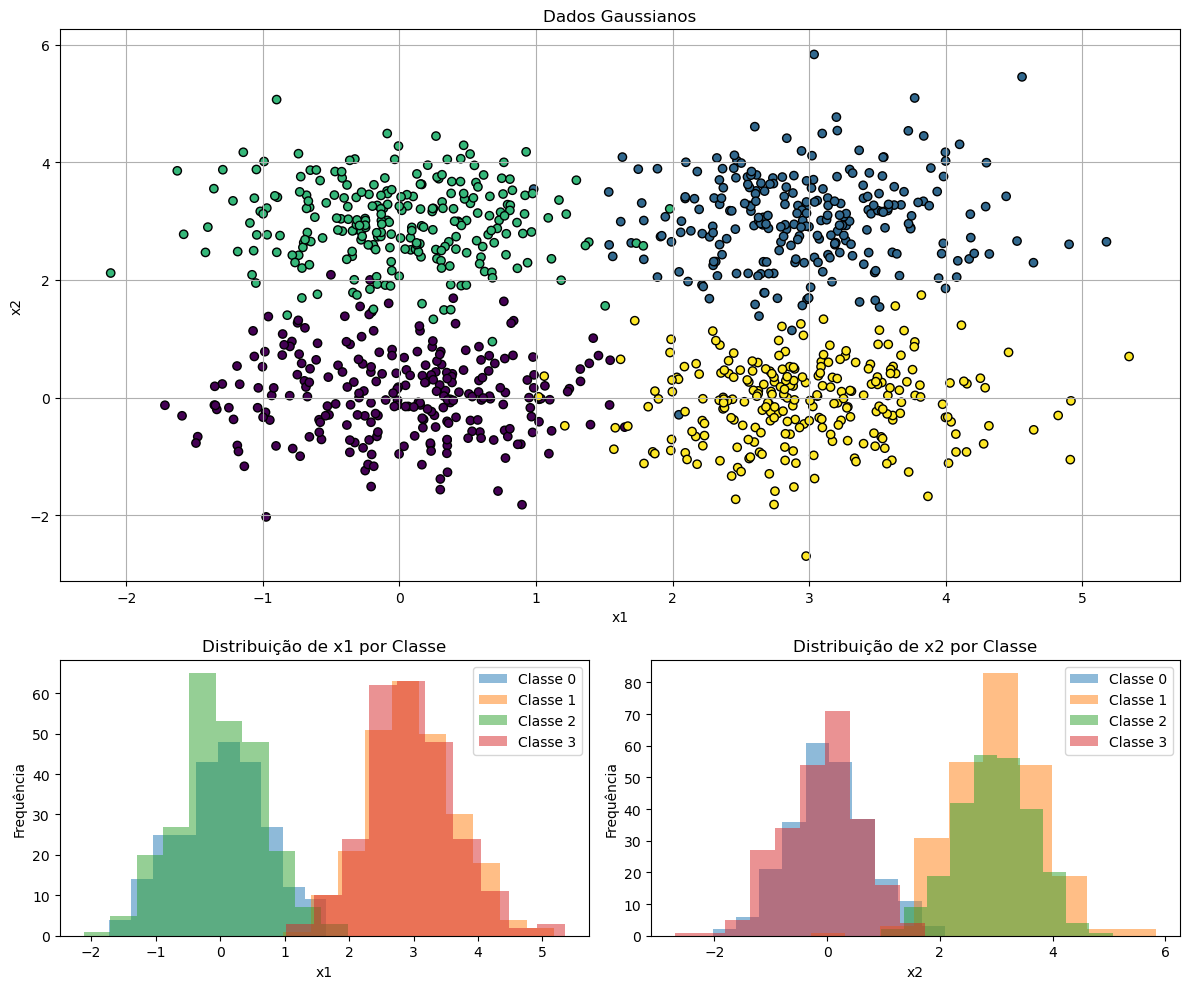

In [4]:
params = {
    "n_classes": 4,
    "n_samples": 1000,
    "means": [[0, 0], [3, 3], [0, 3], [3, 0]],
    "covs": [np.eye(2) * 0.5, np.eye(2) * 0.5, np.eye(2) * 0.5, np.eye(2) * 0.5],
    "priors": [0.25, 0.25, 0.25, 0.25],
    "seed": 42,
}


data, labels, groups = generate_data(**params)

plot_2D(data, labels)

In [5]:
def get_proba(data, **kwargs):
    means = kwargs["means"]
    covs = kwargs["covs"]
    priors = kwargs["priors"]
    n_classes = kwargs["n_classes"]

    prob = np.zeros((data.shape[0], n_classes))
    for i in range(n_classes):
        prob[:, i] = mv_norm(means[i], covs[i]).pdf(data)
        prob[:, i] *= priors[i]

    prob /= np.sum(prob, axis=1, keepdims=True)

    return prob

In [ ]:
def classifier(prob, **kwargs):
    confidence = np.max(prob, axis=1)
    pred = np.argmax(prob, axis=1)
    return pred, confidence


def rejector(confidence, threshold=None):
    index = np.argsort(confidence)[::-1]
    if threshold is None:
        return index
    accepted_indices = index[confidence[index] >= threshold]
    return accepted_indices

In [ ]:
def error(y, y_pred):
    error = np.mean(y != y_pred)
    return error


def balanced_error(y, y_pred):
    classes = np.unique(y)
    class_errors = []
    for cls in classes:
        cls_mask = y == cls
        cls_error = np.mean(y_pred[cls_mask] != cls)
        class_errors.append(cls_error)
    return np.mean(class_errors)


def worst_group_error(y, y_pred):
    unique_groups = np.unique(y)
    group_errors = []
    for group in unique_groups:
        group_mask = y == group
        group_error = np.mean(y_pred[group_mask] != y[group_mask])
        group_errors.append(group_error)
    return np.max(group_errors)

# Geração e predição


In [25]:
params_1 = {
    "n_classes": 3,
    "means": [(-2, -2), (2, 2), (0, 0)],
    "covs": [[[0.5, 0], [0, 0.5]], [[0.5, 0], [0, 0.5]], [[0.5, 0], [0, 0.5]]],
    "priors": [0.3, 0.4, 0.3],
    "n_samples": 1000,
    "seed": 77,
}

data, labels, groups = generate_data(**params_1)

prob = get_proba(data, **params_1)

pred, confidence = classifier(prob)

c:\Users\davis\miniconda3\envs\prob-ml\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\davis\miniconda3\envs\prob-ml\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


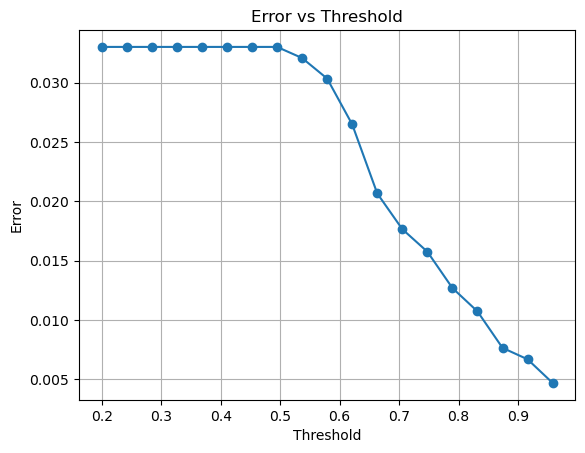

In [26]:
# plot curva de Erro vs limiar aceito
thresholds = np.linspace(0.2, 1, 20)

errors = []
for threshold in thresholds:
    masked = rejector(confidence, threshold)
    y_pred_masked = pred[masked]
    y_true_masked = labels[masked]
    acc = error(y_true_masked, y_pred_masked)
    errors.append(acc)

plt.plot(thresholds, errors, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title("Error vs Threshold")
plt.grid()
plt.show()

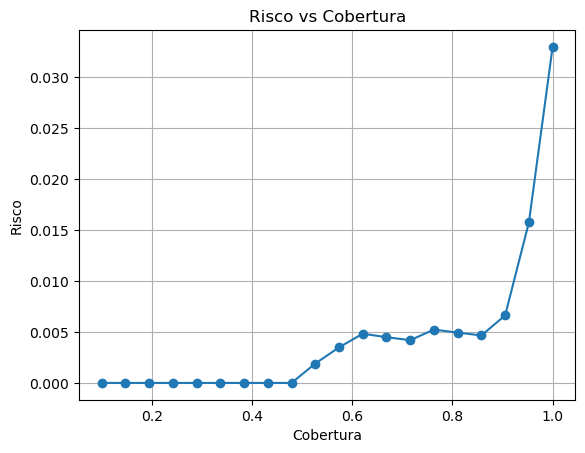

In [29]:
# plotar uma curva RC

coberturas = np.linspace(0.1, 1, 20)

risco = []
for cobertura in coberturas:
    masked = rejector(confidence)
    masked = masked[: int(len(masked) * cobertura)]
    y_pred_masked = pred[masked]
    y_true_masked = labels[masked]
    acc = error(y_true_masked, y_pred_masked)
    risco.append(acc)

plt.plot(coberturas, risco, marker="o")
plt.xlabel("Cobertura")
plt.ylabel("Risco")
plt.title("Risco vs Cobertura")
plt.grid()
plt.show()

In [48]:
# plot dos dados com limiar


def plot_thresholds(data: np.array, labels: np.array, thresholds: list) -> None:

    n_plots = len(thresholds) - 1

    fig, ax = plt.subplots(n_plots, figsize=(12, 10))

    for i, threshold in enumerate(thresholds[1:]):
        mask = rejector(confidence, threshold)
        masked_data = data[mask]
        masked_labels = labels[mask]

        ax[i].scatter(
            masked_data[:, 0],
            masked_data[:, 1],
            c=masked_labels,
            cmap="viridis",
            edgecolor="k",
            alpha=0.5,
        )
        ax[i].set_title(f"Máscara com {threshold=} - {masked_data.shape[0]} amostras")
        ax[i].grid()

    plt.tight_layout()
    plt.show()

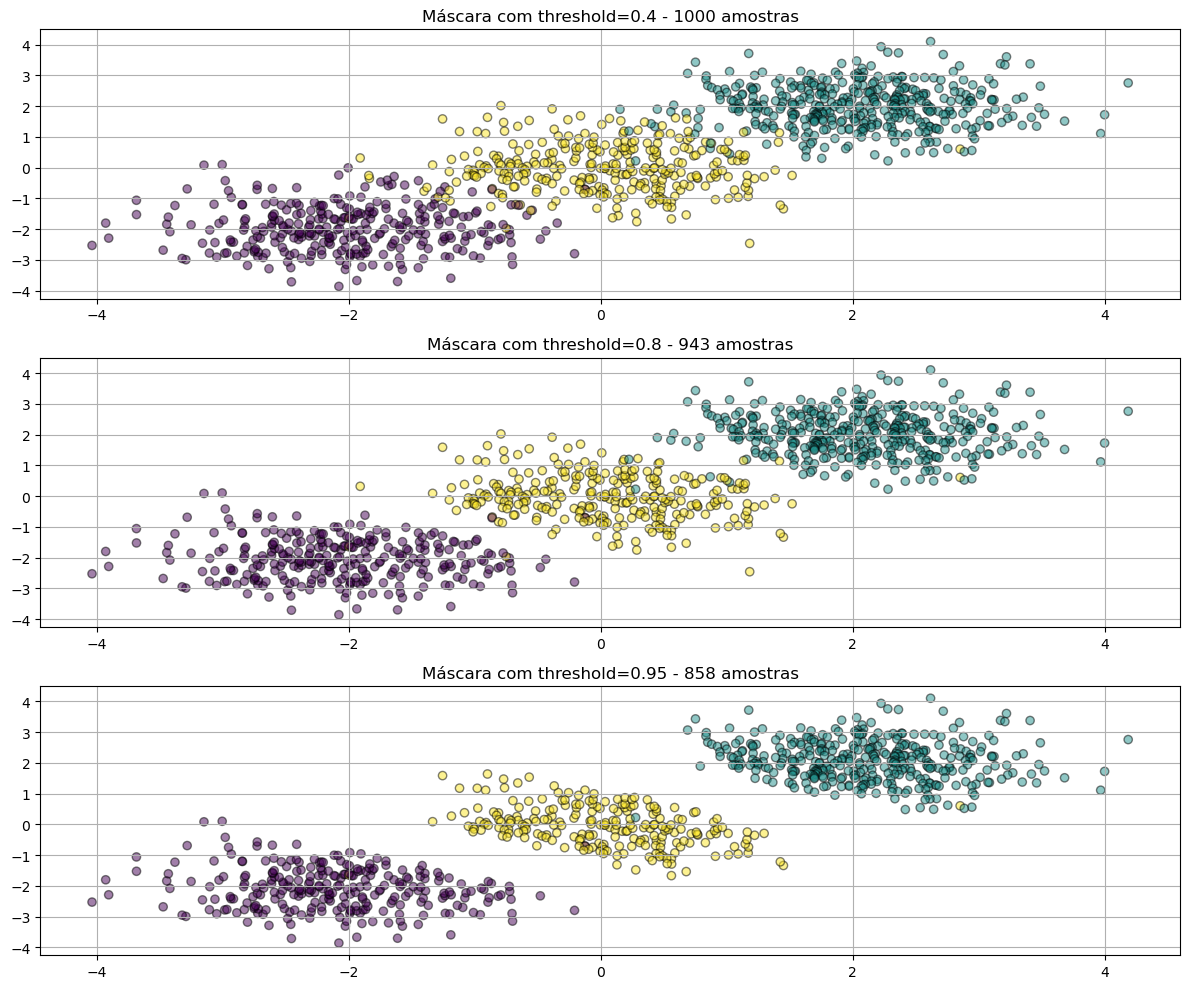

In [49]:
t_tests = [0, 0.4, 0.8, 0.95]
plot_thresholds(data, labels, t_tests)